Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.

# Elementos finitos en 1D

Queremos resolver al ecuación de Poisson en 1D usando
el método de elementos finitos.

$$\frac{d^2 u}{dx^2} = f(x)\, ,$$

con $u(0) = u(1)  = 0$.

Vamos a usar una solución aproximada de la forma

$$u(x) = \sum_{n=0}^{N} u_n \phi_n(x)\, ,$$

Si usamos el método de Galerkin, la ecuación diferencial es equivalente
al siguiente problema

$$-\int_{0}^{1} \frac{d u}{d x} \frac{d \phi_n}{d x} dx
= \int_{0}^{1}  \phi_n f(x) dx\, \quad \forall \phi_n\, .$$

Si remplazamos $u(x)$ en este sistema obtenemos

$$\sum_{j=0}^N \left[\int_{0}^{1} \frac{d \phi_i}{d x} \frac{d \phi_j}{d x} dx\right] u_j
= \int_{0}^{1}  \phi_j f(x) dx\, \quad \forall \phi_j\, .$$

Esto lleva al siguiente sistema de ecuaciones

$$[K]\{\mathbf{u}\} = \{\mathbf{b}\}$$

donde las matrices de rigidez locales están dadas por

$$K_\text{local} =  \frac{1}{2 |J|}\begin{bmatrix} 1 & -1\\ -1 &1\end{bmatrix}$$

y

$$b_\text{local} = -|J|\begin{bmatrix} f(x_m)\\ f(x_{m})\end{bmatrix}\, ,$$

donde $|J|$ es el determinante jacobian de la transformación y $x_m$ es
el punto medio del elemento. Acá estamos asumiendo que el término fuente
es constante sobre el elemento. Bien podríamos usar una mejor aproximación
para esta integral.


<div class="alert alert-warning">

Acá estamos dejando por fuera muchos detalles del ensamblaje de la
matriz y del mapeo del ordenamiento local al global.
</div>

In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [5]:
def FEM1D(coords, source):
    N = len(coords)
    stiff_loc = np.array([[1/2, -1/2],
                        [-1/2, 1/2]])
    eles = [np.array([cont, cont + 1]) for cont in range(0, N - 1)]
    stiff = np.zeros((N, N))
    rhs = np.zeros(N)
    for ele in eles:  ## Ensamblaje
        jaco = 0.5*(coords[ele[1]] - coords[ele[0]])
        x_mid = np.mean(coords[ele])
        rhs[ele] += - jaco*source(np.array([x_mid, x_mid]))
        for cont1, row in enumerate(ele):
            for cont2, col in enumerate(ele):
                stiff[row, col] += stiff_loc[cont1, cont2]/jaco
    return stiff, rhs

Probemos la implementación con la función $f(x) = 20 x^3$, que lleva a
la solución

$$u(x) = x (x^4 - 1)$$

In [6]:
N = 100
N_eval = 200
fun = lambda x: 20*x**3
x = np.linspace(0, 1, N)
x_eval = np.linspace(0, 1, N_eval)


Podemo usar ``FEM1D`` para obtener la matriz de rigidez y el vector de cargas.

In [7]:
stiff, rhs = FEM1D(x, fun)

Y esta matriz y vector podemos usarla para resolver el sistema de ecuaciones
resultante con ``np.linalg.solve``.

En este caso no tomamos la matriz completa sino que dejamos por
fuera las filas/columnas correspondientes al primer y último
grado de libertad ya que tenemos condiciones de Dirichlet homogéneas.

In [8]:
sol = np.zeros(N)
sol[1:-1] = np.linalg.solve(stiff[1:-1, 1:-1], rhs[1:-1])

Podemos comparar la solución numérica con la solución analítica.

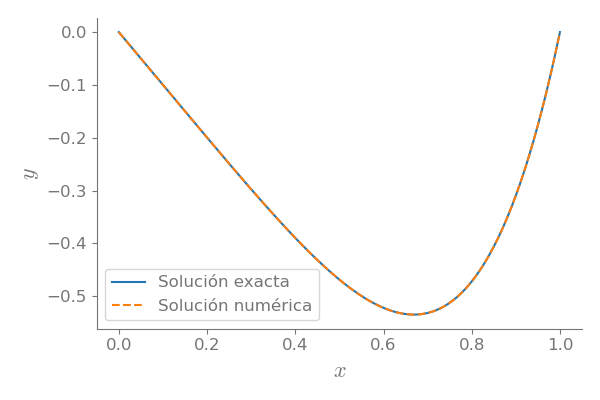

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(x_eval, x_eval*(x_eval**4 - 1))
plt.plot(x, sol, linestyle="dashed")
plt.xlabel(r"$x$", fontsize=16)
plt.ylabel(r"$y$", fontsize=16)
plt.legend(["Solución exacta", "Solución numérica"])
plt.tight_layout()
plt.show()



<div class="alert-info">
    
Pruebe a cambiar el número de nodos usados.

</div>